In [2]:
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import os

c:\Users\savva\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Импорт всех фоток с репозитория
dataset = load_dataset("tukey/documents_email", split="train")
os.makedirs("downloaded_images", exist_ok=True)

for i, example in enumerate(dataset):
    # 'image' — это стандартное имя колонки для картинок
    example['image'].save(f"downloaded_images/img_{i}.jpg")


c:\Users\savva\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#Сбор кол-ва классов по всем фоткам
labels_path = "./ResultMark Dataset/data/labels/train"  # путь к папке
counter = Counter()

for file in os.listdir(labels_path):
    if file.endswith(".txt"):
        with open(os.path.join(labels_path, file), "r") as f:
            for line in f:
                class_id = int(line.split()[0])
                counter[class_id] += 1

print(counter)

Counter({2: 188, 1: 185, 4: 185, 0: 185, 5: 181, 3: 134})


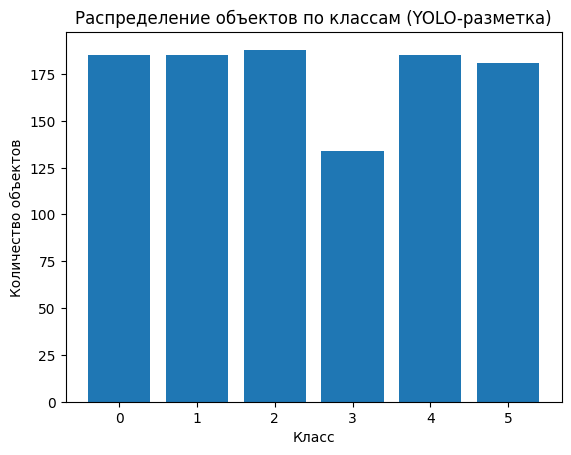

In [5]:
#Построение графика для визуализации
data = counter

# sort by class id
classes = sorted(data.keys())
values = [data[c] for c in classes]

plt.figure()
plt.bar([str(c) for c in classes], values)
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение объектов по классам (YOLO-разметка)")

plt.savefig('./DiagrammYolo.png')
plt.show()

In [6]:
labels_path = "./ResultMark Dataset/data/labels/train"
images_path = "./ResultMark Dataset/data/images/train"

image_extensions = [".jpg", ".jpeg", ".png"]

# собираем имена label-файлов (без расширения)
label_names = set()
for file in os.listdir(labels_path):
    if file.endswith(".txt"):
        name = os.path.splitext(file)[0]
        label_names.add(name)

deleted_count = 0

# проверяем изображения
for file in os.listdir(images_path):
    name, ext = os.path.splitext(file)
    
    if ext.lower() in image_extensions:
        if name not in label_names:
            file_path = os.path.join(images_path, file)
            os.remove(file_path)
            deleted_count += 1
            print(f"Удалено изображение: {file}")

print(f"\nВсего удалено изображений: {deleted_count}")

Удалено изображение: img_116.jpg
Удалено изображение: img_182.jpg
Удалено изображение: img_183.jpg
Удалено изображение: img_190.jpg
Удалено изображение: img_200.jpg
Удалено изображение: img_202.jpg
Удалено изображение: img_203.jpg
Удалено изображение: img_207.jpg
Удалено изображение: img_208.jpg
Удалено изображение: img_212.jpg
Удалено изображение: img_214.jpg
Удалено изображение: img_216.jpg
Удалено изображение: img_220.jpg
Удалено изображение: img_225.jpg
Удалено изображение: img_229.jpg
Удалено изображение: img_231.jpg
Удалено изображение: img_234.jpg
Удалено изображение: img_238.jpg
Удалено изображение: img_239.jpg
Удалено изображение: img_24.jpg
Удалено изображение: img_240.jpg
Удалено изображение: img_25.jpg
Удалено изображение: img_256.jpg
Удалено изображение: img_257.jpg
Удалено изображение: img_258.jpg
Удалено изображение: img_259.jpg
Удалено изображение: img_26.jpg
Удалено изображение: img_263.jpg
Удалено изображение: img_269.jpg
Удалено изображение: img_337.jpg

Всего удален